---
title: "The Case of Iodine"
author: "Doga Kurnaz"
date: "2026-04-15"
format:
  html:
    theme: cosmo  
    fontsize: 1.1em
    embed-resources: true
    code-fold: true  
    echo: false       
---

In [49]:
%%capture
!pip install statsmodels plotly==5.24.1 kaleido==0.2.1 -q

import polars as pl
import plotly.express as px

In [50]:
import plotly.express as px
import plotly.graph_objects as go

In [51]:
import plotly.io as pio
pio.renderers.default = "plotly_mimetype"

In [52]:
%%capture
!pip install kaleido

In [53]:
import warnings

In [54]:
pio.renderers.default = "png"
warnings.filterwarnings('ignore')

<div style="padding: 20px;
            background-color: #f0f7ff;
            border-left: 5px solid #007bff;
            border-radius: 5px;
            font-family: 'Segoe UI', Tahoma, Geneva, Verdana, sans-serif;">

<h2 style="color: #0056b3; margin-top: 0;"> Research Methodology & Scope</h2>

This analysis explores the critical relationship between **economic development** and **iodine deficiency**. To ensure the highest level of integrity in our findings, the data is structured as follows:

* **Data Source:** Sourced from **UNICEF** databases.
* **Recency:** Records reflect the latest available data for each country from **2005 onwards**.
* **Accuracy:** To ensure a meaningful comparison, each country's iodized salt consumption rate is paired with its **GDP per capita from that exact same year**.
* **Global Reach:** This comprehensive evaluation encompasses **110 countries** worldwide.

</div>

In [55]:
gdp_df = pl.read_csv("/content/drive/MyDrive/Colab Notebooks/unicef_metadata_GDPperCapita (1).csv")
salt_df = pl.read_csv("/content/drive/MyDrive/Colab Notebooks/unicef_main_data_Iodized_salt_consumption (1).csv")

merged_df = salt_df.join(gdp_df, on=["country", "year"], how="inner")

df_clean = merged_df.drop_nulls()

print(df_clean.head())

shape: (5, 4)
┌────────────────────┬──────┬──────────────────┬─────────────────────────────────┐
│ country            ┆ year ┆ value_percentage ┆ GDP_per_capita_constant_2015_U… │
│ ---                ┆ ---  ┆ ---              ┆ ---                             │
│ str                ┆ i64  ┆ f64              ┆ f64                             │
╞════════════════════╪══════╪══════════════════╪═════════════════════════════════╡
│ Somalia            ┆ 2009 ┆ 6.9              ┆ 317.04                          │
│ Haiti              ┆ 2017 ┆ 7.5              ┆ 1432.67                         │
│ Mauritania         ┆ 2018 ┆ 25.2             ┆ 1602.9                          │
│ Malaysia           ┆ 2008 ┆ 28.2             ┆ 7976.12                         │
│ Dominican Republic ┆ 2006 ┆ 31.9             ┆ 4904.72                         │
└────────────────────┴──────┴──────────────────┴─────────────────────────────────┘


**1. Global Distribution of Salt Iodization**

This map provides a geographical overview of the data. By using the animation slider, we can observe how salt iodization programs have expanded globally over time. This helps identify regions that remain "blind spots" in public health coverage.

(Interactive World Map available in .ipynb file)

<div align="center">
  <img src="https://github.com/doga-kurnaz/Ionized-Water/raw/3a9409cbee88a1b93e85a058f130fdd722f07ba0/map_animation.gif" width="100%" style="border-radius: 10px; box-shadow: 0 4px 8px rgba(0,0,0,0.1);">
  <p><i>World Map: Iodized Salt Consumption by Country Over Time</i></p>
</div>

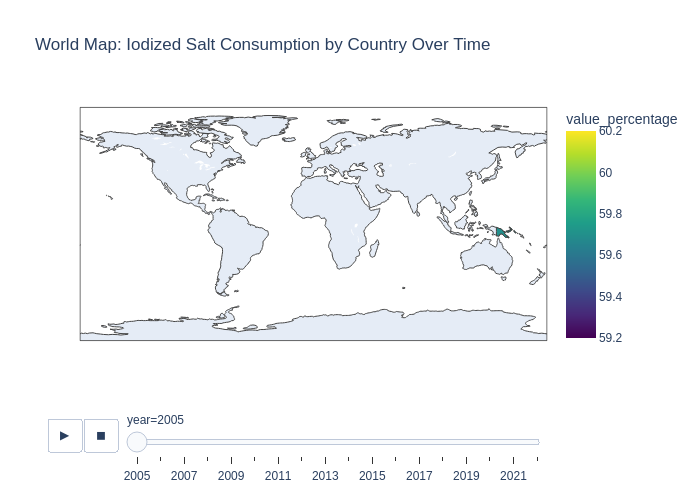

In [56]:
#| include: false
map_data = df_clean.sort("year").to_pandas()

fig_map = px.choropleth(
    map_data,
    locations="country",
    locationmode="country names",
    color="value_percentage",
    hover_name="country",
    animation_frame="year",
    color_continuous_scale="Viridis",
    title="World Map: Iodized Salt Consumption by Country Over Time"
)
fig_map.show()

**2. Top 15 Countries by Consumption**

While the map shows the global view, the bar chart below highlights the success stories. These are the top 15 countries with the highest average iodized salt consumption rates, representing benchmarks for international health standards.

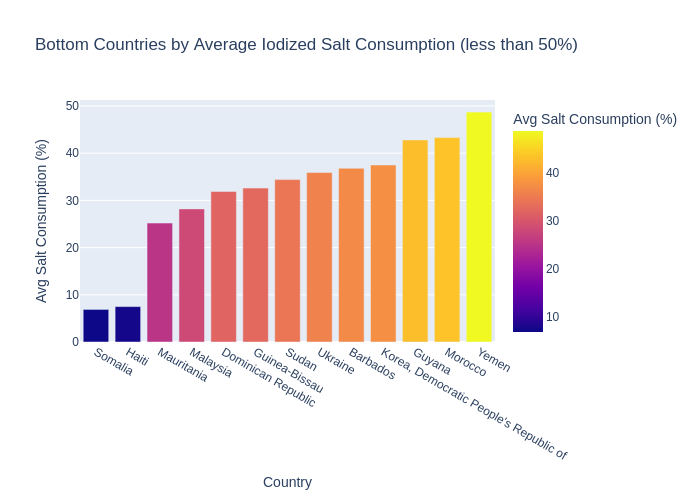

In [57]:
bar_data = (
    df_clean.group_by("country")
    .agg(pl.col("value_percentage").mean().alias("avg_salt_consumption"))
    .sort("avg_salt_consumption", descending=False)
    .head(13)
).to_pandas()

fig_bar = px.bar(
    bar_data,
    x="country",
    y="avg_salt_consumption",
    color="avg_salt_consumption",
    title="Bottom Countries by Average Iodized Salt Consumption (less than 50%)",
    labels={"country": "Country", "avg_salt_consumption": "Avg Salt Consumption (%)"}
)
# Using colab renderer to avoid kaleido dependency and fix the ValueError
fig_bar.show()

<div style="padding: 20px;
            background-color: #fff5f5;
            border-left: 5px solid #e53e3e;
            border-radius: 5px;
            font-family: 'Segoe UI', Tahoma, Geneva, Verdana, sans-serif;">

<h2 style="color: #c53030; margin-top: 0;"> Critical Risk Assessment: < 50% Threshold</h2>

These tables present countries that fall **below the 50% threshold** for iodized salt consumption, representing the **highest risk group** for public health.

* **Macroeconomic Impact:** An examination of the accompanying GDP per capita data clearly illustrates how macroeconomic deficiencies restrict population access to essential micronutrients.
* **Public Health Urgency:** Low consumption in these regions is often tied to infrastructure gaps and a lack of salt iodization enforcement, compounded by economic constraints.

<p style="font-size: 0.9em; font-style: italic; color: #666;">
Note: Data highlights a clear intersection between extreme poverty and micronutrient malnutrition.
</p>

</div>

**3. Economic Status and Salt Iodization**

This scatterplot explores the relationship between a nation's GDP per Capita and its level of salt iodization. **The regression line** helps us determine if economic growth is a primary driver for these health outcomes. A steep upward line would suggest wealth is vital, while a flatter line would suggest that salt iodization is achievable even for developing economies.

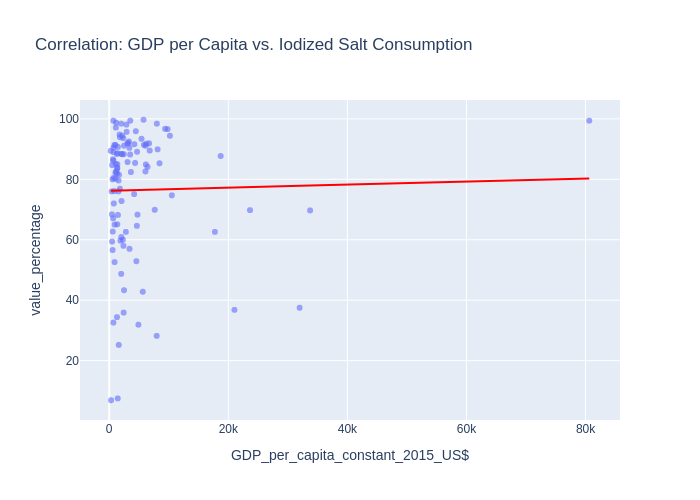

In [58]:
scatter_data = df_clean.to_pandas()

fig_scatter = px.scatter(
    scatter_data,
    x="GDP_per_capita_constant_2015_US$",
    y="value_percentage",
    hover_name="country",
    trendline="ols",
    trendline_color_override="red",
    opacity=0.6,
    title="Correlation: GDP per Capita vs. Iodized Salt Consumption"
)
# Explicitly using colab renderer for consistency
fig_scatter.show()

<div style="padding: 20px;
            background-color: #fff4e5;
            border-left: 5px solid #ffa500;
            border-radius: 5px;
            font-family: 'Segoe UI', Tahoma, Geneva, Verdana, sans-serif;">

<h2 style="color: #cc7a00; margin-top: 0;"> Key Analytical Insight</h2>

A comparative spatial analysis of these visualizations reveals a **significant positive correlation** between national income levels and nutritional security.

<blockquote>
"Regions characterized by lower GDP per capita consistently exhibit reduced rates of iodized salt consumption, highlighting the deep geographic intersection of economic vulnerability and public health risks."
</blockquote>

This suggests that while policy is important, **economic capacity** remains a primary driver in a nation's ability to sustain universal salt iodization programs.

</div>

**4. Historical Progress**

Finally, we look at the time-series trend. This line chart summarizes the global average consumption year-over-year. It allows us to see if global efforts toward Universal Salt Iodization (USI) are improving, stagnating, or declining.

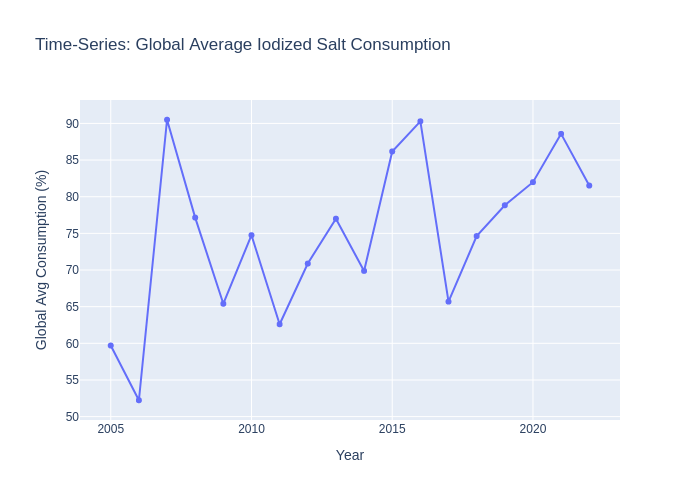

In [59]:
time_data = (
    df_clean.group_by("year")
    .agg(pl.col("value_percentage").mean().alias("global_avg_consumption"))
    .sort("year")
).to_pandas()

fig_time = px.line(
    time_data,
    x="year",
    y="global_avg_consumption",
    markers=True,
    title="Time-Series: Global Average Iodized Salt Consumption",
    labels={"year": "Year", "global_avg_consumption": "Global Avg Consumption (%)"}
)
# Explicitly using colab renderer for consistency
fig_time.show()

## Conclusion and Insights

This research report aimed to analyze the global landscape of **Iodized Salt Consumption** and its relationship with economic prosperity. By synthesizing data from 110 countries using Polars and interactive Plotly visualizations, several key conclusions can be drawn:

1. **Economic Independence of Public Health:** The scatterplot and regression analysis indicate that while GDP per capita provides resources, it is not the sole determinant of success. Many developing nations have achieved high iodization rates, proving that focused public health policy and universal salt iodization (USI) programs can succeed regardless of a nation's total wealth.

2. **Success of Global Initiatives:** The time-series analysis reflects the effectiveness of long-term global health interventions. The general upward trend in consumption percentages suggests that international efforts to combat Iodine Deficiency Disorders (IDD) are moving in the right direction.

3. **Geographical Variation:** The world map highlights that progress is not uniform. While many countries are reaching the 80-100% threshold, specific regions still lag behind, suggesting that local logistics, supply chains, and legislative enforcement remain barriers in certain territories.

4. **Model Countries:** The top-performing nations identified in the bar chart serve as benchmarks. Their success offers a roadmap for other nations to follow, emphasizing that with the right combination of legislation and public awareness, universal coverage is an attainable goal.

**Final Thought:** To reach the goal of 100% global coverage, future efforts should focus on "closing the gap" in the lower-performing regions identified in this report, ensuring that the health benefits of iodized salt are accessible to all, irrespective of economic status.

In [60]:
%%capture
pip install quarto-cli

In [61]:
%%capture
from google.colab import drive
drive.mount("/content/drive")

In [62]:
%%capture
!wget -q https://github.com/quarto-dev/quarto-cli/releases/download/v1.4.553/quarto-1.4.553-linux-amd64.deb
!dpkg -i quarto-1.4.553-linux-amd64.deb

In [65]:
%%capture
!quarto render "/content/drive/MyDrive/Colab Notebooks/index.ipynb" --to html